# Multi Planar Flows

*Oct 8, 2024*

**[Javad Komijani (ETH Zurich)](mailto:jkomijani@gmail.com)**

## Introduction
Rezende and Mohamed in [arXiv:1505.05770](https://arxiv.org/pdf/1505.05770),
introduced planar flows, which take the form
$$
    \mathbf{y} = \mathbf{x} + \mathbf{u} h(\mathbf{w}^\top \mathbf{x}) .
$$
Here $\mathbf{x}, \mathbf{u}, \mathbf{w} \in \mathbb{R}^n$,
and $h(·)$ is a smooth element-wise non-linearity.
These flows are relatively simple and can be inverted subject to certain conditions.

A generalization of the planar flows are introduce in [arXiv:1803.05649](https://arxiv.org/pdf/1803.05649) as
$$
    \mathbf{y} = \mathbf{x} + \mathbf{U} h(\mathbf{W}^\top \mathbf{x})
$$
with $\mathbf{U}, \mathbf{W} \in \mathbb{R}^{n\times m}$.
They consider $\mathbf{U} = \mathbf{Q R}$ and $\mathbf{W} = \mathbf{Q \tilde R}$
where $\mathbf{R}$ and $\mathbf{\tilde R}$ are triangular matrices and thes discuss the
conditions of invetability.

## Extension of planar flows

For a vector $X \in \mathbb{R}^n$, consider the following transformation:

$$
    \mathbf{y} = \mathbf{W} \mathbf{S}\, h_1(\mathbf{W}^\top \mathbf{x})
    + \mathbf{P} \left[\mathbf{x} \left(1 + \mathbf{a}^\top h_2(\mathbf{W}^\top \mathbf{x})\right)
              + \mathbf{U} h_3(\mathbf{W}^\top \mathbf{x})\right]
$$

where $\mathbf{W}, \mathbf{U} \in \mathbb{R}^{n\times m}$;
$\mathbf{a} \in \mathbb{R}^m$;
$\mathbf{S}$ is an $m\times m$ invertible matrix;
$\mathbf{P}$ is an $n\times n$ projection matrix perpendicular to $\mathbf{W}$;
$h_1(.)$ is an elementwise, invertible function;
both $h_2(.)$ and $h_3(.)$ are arbitrary functions,
but $h_2(.)$ satisfies
$$
    \mathbf{a}^\dagger h_2(\mathbf{W}^\top \mathbf{x}) > -1.
$$
Furthermore, we assume $\mathbf{\Sigma} = \mathbf{W}^\top \mathbf{W}$ is invertible,
and we define the projection matrix as $\mathbf{P} = \mathbf{I} - \mathbf{W} \mathbf{\Sigma}^{-1} \mathbf{W}^\top$.


We now show that the introduced transformation is invertible.
To this end, we first mutiply the above relation by $\mathbf{W}^\top$:
$$
    \mathbf{W}^\top \mathbf{y} = \mathbf{\Sigma} \mathbf{S}\, h_1(\mathbf{W}^\top \mathbf{x})
    \quad\Rightarrow\quad
    \mathbf{W}^\top \mathbf{x} = h_1^{-1}\left(\mathbf{S}^{-1} \mathbf{\Sigma}^{-1} \mathbf{W}^\top \mathbf{y}\right);
$$
this yields $\mathbf{x}_{||} = \mathbf{W}^\top \mathbf{x}$.
We now multiply the transformation by $\mathbf{P}$:
$$
\begin{align}
    \mathbf{P} \mathbf{y} &= \mathbf{P} \left[\mathbf{x} + \mathbf{x} \mathbf{a}^\top h_2(\mathbf{x}_{||}) + \mathbf{U} h_3(\mathbf{x}_{||})\right]
    \\
    \Rightarrow\quad
    \mathbf{P} \mathbf{x} &= \mathbf{P} \frac{\mathbf{y} - \mathbf{U} h_3(\mathbf{x}_{||})}{1 + \mathbf{a}^\top h_2(\mathbf{x}_{||})}.
\end{align}
$$

We now calculate the Jacobian of transformation.
First we observe that the Jacobian matrix can be block diagonalized as
$$
\begin{align}
    \mathbf{P}_c \frac{\partial \mathbf{y}}{\partial \mathbf{x}} \mathbf{P}_c
    &= \mathbf{W} \mathbf{S} \frac{\partial h_1(\mathbf{x}_{||})}{\partial \mathbf{x}_{||}} \mathbf{W}^\top
    \\
    \mathbf{P} \frac{\partial \mathbf{y}}{\partial \mathbf{x}} \mathbf{P}
    &=
    \mathbf{P} \left(1 + \mathbf{a}^\top h_2(\mathbf{x}_{||})\right)
    \\
    \mathbf{P}_c \frac{\partial \mathbf{y}}{\partial \mathbf{x}} \mathbf{P} &= 0
\end{align}
$$
where 
$\mathbf{P}_c = \mathbf{I} - \mathbf{P} = \mathbf{W} \mathbf{\Sigma}^{-1} \mathbf{W}^\top$.
Therefore, the logarithm of the determint reads
$$
    \ln J = \ln \left| \text{det}\left(\frac{\partial h_1(\mathbf{x}_{||})}{\partial \mathbf{x}_{||}}\right)\right|
    +
    \ln |\text{det} (\mathbf{\Sigma S})|
    +
    (n - m) \ln \left(1 + \mathbf{a}^\top h_2(\mathbf{x}_{||})\right)
$$
where $n - m$ is rank of the projection matrix $\mathbf{P}$.
Note that $h_1(.)$ is elementwise, and its Jacobian matrix is diagonal.


The introduced transformation is a generalization of both planar and radial flows.
For instance setting $\mathbf{U} = -\mathbf{x}_0 \mathbf{a}^\top$ and $h_3 = h_2$, one obtains a
transformation that acts like a set of radial transformation on the hyper plane.

### MultiPlanarFlow_

For simple choices of nonlinearities for $h_2$ and $h_3$, we observe that the corresponding terms do not play any important roles.
Therefore, we set them to zero in `MultiPlanarFlow_`.
Moreover, we set $S = \Sigma$ to simplify the transformation.
For the nonlinearity, if not provided by the user, by default `MultiPlanarFlow_` uses a combination of `Pade32_` and `Affine_`

In [1]:
import normflow
import torch
import numpy as np
from typing import Union, Callable

import matplotlib.pyplot as plt

from normflow import Model
from normflow.nn import Module_
from normflow.nn import ModuleList_

from normflow.nn import Pade32a_

In [2]:
class MultiPlanarFlow_(Module_):
    """Performs a transformation as                                             
                                                                                
    .. math::                                                                   
                                                                                
        Y = W \Sigma^{-1} h(W^\dagger X) + P X.                                 
                                                                                
    Here `X` and `Y` are vectors of size `n`, `W` is a matrix of size `[n, m]`, 
    where `m` specifies the number of (hidden) channels of transformation,      
    `\Sigma = W^\dagger W`, `P` is a projection matrix perpendicular to `W`,    
    and `h` is an invertible nonlinearity.                                      
                                                                                
    Rezende and Mohamed [arXiv:1505.05770] introduced planar flows, which take  
    the form ``Y = X + U h(W^\dagger X)``, with ``m = 1``. The transformation   
    used here is a genarlization of planar flow to ``m`` channels and with a
    projection matrix.
                                                                                
    Parameters                                                                  
    ----------                                                                  
    n: int                                                                      
        lenght of the outermost axix of input                                   
    m: int                                                                      
        number of (hidden) channels                                             
    net_: Union[Callable, None], optional                                       
        an implementation of `h` that transforms the projected data and also
        returns `logj` of transformation. If not provided as input, the default 
        case would be used, which is ``net_ = Pade32a_(n_channels=m)``.        
    """
    def __init__(self, 
                 n: int,
                 m: int,
                 net_: Union[Callable, None] = None,
                 set_param2zero: bool = True
                ):
        
        assert n > 1 and m > 0, "Appropriate only for n > 1 & m > 0"
            
        def make_parameters(*shape):
            var = torch.randn(*shape)
            return torch.nn.Parameter(var / torch.norm(var))

        super().__init__()

        self.n_dim = n
        self.m_dim = m

        self.w_mat = make_parameters(1, n, m)
        self.eye = torch.eye(n).unsqueeze(0)
        
        if net_ is None:
            # if m > 1 set n_channels = m & channels axis = 1
            net_ = Pade32a_(channels_axis = None if m==1 else 1, n_channels=m)
            
        self.net_ = net_

        if set_param2zero:
            self.set_param2zero()
        
    def forward(self, x, log0=0):
        
        assert x.shape[-1] == self.n_dim, "inconsistent input"

        x_shape = x.shape  # keep for later use
        x = x.reshape(-1, self.n_dim, 1)

        w_mat = self.eye[..., :self.m_dim] + self.w_mat
        ws_mat = w_mat @ torch.linalg.inv(w_mat.adjoint() @ w_mat)

        y_parallel, logj = self.net_.forward(w_mat.adjoint() @ x)

        y = ws_mat @ y_parallel + (self.eye - ws_mat @ w_mat.adjoint()) @ x
        
        return y.reshape(*x_shape), log0 + logj

    def reverse(self, y, log0=0):
        
        assert y.shape[-1] == self.n_dim, "inconsistent input"

        y_shape = y.shape  # keep for later use
        y = y.reshape(-1, self.n_dim, 1)
        
        w_mat = self.eye[..., :self.m_dim] + self.w_mat
        ws_mat = w_mat @ torch.linalg.inv(w_mat.adjoint() @ w_mat)
        
        x_parallel, logj = self.net_.reverse(w_mat.adjoint() @ y)
        
        x = ws_mat @ x_parallel + (self.eye - ws_mat @ w_mat.adjoint()) @ y

        return x.reshape(*y_shape), log0 + logj

## Example

Let us define an action and train a model based on `MultiPlanarFlow_`.

In [3]:
class Action0:


    def __init__(self, *args):
        pass
        
    def __call__(self, cfgs):
        x, y = torch.unbind(cfgs, -1)
        return 0.5 * (x**2 + y**2)**0.5
        

class Action1:

    def __init__(self, beta=1):
        self.beta = beta
        
    def __call__(self, cfgs):
        x, y = torch.unbind(cfgs, -1)
        r = (x**2 + y**2)**0.5
        part1 = torch.exp(-(x - 2)**2 / (2 * 0.6**2))
        part2 = torch.exp(-(x + 2)**2 / (2 * 0.6**2))
        part0 = (r - 2)**2 / (2 * 0.4**2)
        return self.beta * (part0 - torch.log(part1 + part2)) + (1 - self.beta) * r**2 / 2

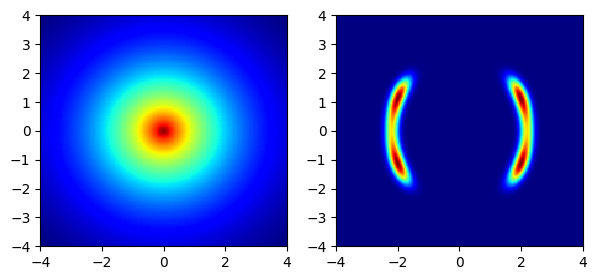

In [4]:
x = np.linspace(-4, 4, 201)
y = np.linspace(-4, 4, 201)
X, Y = np.meshgrid(x, y)

cfgs = torch.tensor(np.stack([X, Y], axis=-1))

fig, axs = plt.subplots(1, 2, figsize=(7, 3))


for k, Action in enumerate([Action0, Action1]):
    Z = torch.exp(-Action(5)(cfgs)).numpy()
    axs[k].pcolormesh(X, Y, Z, cmap=plt.cm.jet);
    axs[k].set_xlim([-4, 4])
    axs[k].set_ylim([-4, 4])

fig.savefig("prior_target.pdf")

del X, Y, Z

In [5]:
prior = normflow.prior.NormalPrior(shape=(2,))
    
net_ = ModuleList_([MultiPlanarFlow_(n=2, m=2) for _ in range(8)])

model1 = Model(prior=prior, net_=net_, action=Action1(5))

print(f"npar = {model1.net_.npar}")

npar = 80


In [6]:
load_pretrained_model = True

if load_pretrained_model:
    weights_blob = 'UEsDBAAACAgAAAAAAAAAAAAAAAAAAAAAAAAQABIAYXJjaGl2ZS9kYXRhLnBrbEZCDgBaWlpaWlpaWlpaWlpaWoACY2NvbGxlY3Rpb25zCk9yZGVyZWREaWN0CnEAKVJxAShYBwAAADAud19tYXRxAmN0b3JjaC5fdXRpbHMKX3JlYnVpbGRfdGVuc29yX3YyCnEDKChYBwAAAHN0b3JhZ2VxBGN0b3JjaApEb3VibGVTdG9yYWdlCnEFWAEAAAAwcQZYAwAAAGNwdXEHSwR0cQhRSwBLAUsCSwKHcQlLBEsCSwGHcQqJaAApUnELdHEMUnENWBAAAAAwLm5ldF8uMC53X3NjYWxlcQ5oAygoaARoBVgBAAAAMXEPaAdLAnRxEFFLAEsChXERSwGFcRKJaAApUnETdHEUUnEVWA8AAAAwLm5ldF8uMC53X2JpYXNxFmgDKChoBGgFWAEAAAAycRdoB0sCdHEYUUsASwKFcRlLAYVxGoloAClScRt0cRxScR1YDAAAADAubmV0Xy4xLndfYXEeaAMoKGgEaAVYAQAAADNxH2gHSwJ0cSBRSwBLAoVxIUsBhXEiiWgAKVJxI3RxJFJxJVgHAAAAMS53X21hdHEmaAMoKGgEaAVYAQAAADRxJ2gHSwR0cShRSwBLAUsCSwKHcSlLBEsCSwGHcSqJaAApUnErdHEsUnEtWBAAAAAxLm5ldF8uMC53X3NjYWxlcS5oAygoaARoBVgBAAAANXEvaAdLAnRxMFFLAEsChXExSwGFcTKJaAApUnEzdHE0UnE1WA8AAAAxLm5ldF8uMC53X2JpYXNxNmgDKChoBGgFWAEAAAA2cTdoB0sCdHE4UUsASwKFcTlLAYVxOoloAClScTt0cTxScT1YDAAAADEubmV0Xy4xLndfYXE+aAMoKGgEaAVYAQAAADdxP2gHSwJ0cUBRSwBLAoVxQUsBhXFCiWgAKVJxQ3RxRFJxRVgHAAAAMi53X21hdHFGaAMoKGgEaAVYAQAAADhxR2gHSwR0cUhRSwBLAUsCSwKHcUlLBEsCSwGHcUqJaAApUnFLdHFMUnFNWBAAAAAyLm5ldF8uMC53X3NjYWxlcU5oAygoaARoBVgBAAAAOXFPaAdLAnRxUFFLAEsChXFRSwGFcVKJaAApUnFTdHFUUnFVWA8AAAAyLm5ldF8uMC53X2JpYXNxVmgDKChoBGgFWAIAAAAxMHFXaAdLAnRxWFFLAEsChXFZSwGFcVqJaAApUnFbdHFcUnFdWAwAAAAyLm5ldF8uMS53X2FxXmgDKChoBGgFWAIAAAAxMXFfaAdLAnRxYFFLAEsChXFhSwGFcWKJaAApUnFjdHFkUnFlWAcAAAAzLndfbWF0cWZoAygoaARoBVgCAAAAMTJxZ2gHSwR0cWhRSwBLAUsCSwKHcWlLBEsCSwGHcWqJaAApUnFrdHFsUnFtWBAAAAAzLm5ldF8uMC53X3NjYWxlcW5oAygoaARoBVgCAAAAMTNxb2gHSwJ0cXBRSwBLAoVxcUsBhXFyiWgAKVJxc3RxdFJxdVgPAAAAMy5uZXRfLjAud19iaWFzcXZoAygoaARoBVgCAAAAMTRxd2gHSwJ0cXhRSwBLAoVxeUsBhXF6iWgAKVJxe3RxfFJxfVgMAAAAMy5uZXRfLjEud19hcX5oAygoaARoBVgCAAAAMTVxf2gHSwJ0cYBRSwBLAoVxgUsBhXGCiWgAKVJxg3RxhFJxhVgHAAAANC53X21hdHGGaAMoKGgEaAVYAgAAADE2cYdoB0sEdHGIUUsASwFLAksCh3GJSwRLAksBh3GKiWgAKVJxi3RxjFJxjVgQAAAANC5uZXRfLjAud19zY2FsZXGOaAMoKGgEaAVYAgAAADE3cY9oB0sCdHGQUUsASwKFcZFLAYVxkoloAClScZN0cZRScZVYDwAAADQubmV0Xy4wLndfYmlhc3GWaAMoKGgEaAVYAgAAADE4cZdoB0sCdHGYUUsASwKFcZlLAYVxmoloAClScZt0cZxScZ1YDAAAADQubmV0Xy4xLndfYXGeaAMoKGgEaAVYAgAAADE5cZ9oB0sCdHGgUUsASwKFcaFLAYVxooloAClScaN0caRScaVYBwAAADUud19tYXRxpmgDKChoBGgFWAIAAAAyMHGnaAdLBHRxqFFLAEsBSwJLAodxqUsESwJLAYdxqoloAClScat0caxSca1YEAAAADUubmV0Xy4wLndfc2NhbGVxrmgDKChoBGgFWAIAAAAyMXGvaAdLAnRxsFFLAEsChXGxSwGFcbKJaAApUnGzdHG0UnG1WA8AAAA1Lm5ldF8uMC53X2JpYXNxtmgDKChoBGgFWAIAAAAyMnG3aAdLAnRxuFFLAEsChXG5SwGFcbqJaAApUnG7dHG8UnG9WAwAAAA1Lm5ldF8uMS53X2FxvmgDKChoBGgFWAIAAAAyM3G/aAdLAnRxwFFLAEsChXHBSwGFccKJaAApUnHDdHHEUnHFWAcAAAA2LndfbWF0ccZoAygoaARoBVgCAAAAMjRxx2gHSwR0cchRSwBLAUsCSwKHcclLBEsCSwGHccqJaAApUnHLdHHMUnHNWBAAAAA2Lm5ldF8uMC53X3NjYWxlcc5oAygoaARoBVgCAAAAMjVxz2gHSwJ0cdBRSwBLAoVx0UsBhXHSiWgAKVJx03Rx1FJx1VgPAAAANi5uZXRfLjAud19iaWFzcdZoAygoaARoBVgCAAAAMjZx12gHSwJ0cdhRSwBLAoVx2UsBhXHaiWgAKVJx23Rx3FJx3VgMAAAANi5uZXRfLjEud19hcd5oAygoaARoBVgCAAAAMjdx32gHSwJ0ceBRSwBLAoVx4UsBhXHiiWgAKVJx43Rx5FJx5VgHAAAANy53X21hdHHmaAMoKGgEaAVYAgAAADI4cedoB0sEdHHoUUsASwFLAksCh3HpSwRLAksBh3HqiWgAKVJx63Rx7FJx7VgQAAAANy5uZXRfLjAud19zY2FsZXHuaAMoKGgEaAVYAgAAADI5ce9oB0sCdHHwUUsASwKFcfFLAYVx8oloAClScfN0cfRScfVYDwAAADcubmV0Xy4wLndfYmlhc3H2aAMoKGgEaAVYAgAAADMwcfdoB0sCdHH4UUsASwKFcflLAYVx+oloAClScft0cfxScf1YDAAAADcubmV0Xy4xLndfYXH+aAMoKGgEaAVYAgAAADMxcf9oB0sCdHIAAQAAUUsASwKFcgEBAABLAYVyAgEAAIloAClScgMBAAB0cgQBAABScgUBAAB1fXIGAQAAWAkAAABfbWV0YWRhdGFyBwEAAGgAKVJyCAEAAChYAAAAAHIJAQAAfXIKAQAAWAcAAAB2ZXJzaW9ucgsBAABLAXNYAQAAADByDAEAAH1yDQEAAGoLAQAASwFzWAYAAAAwLm5ldF9yDgEAAH1yDwEAAGoLAQAASwFzWAgAAAAwLm5ldF8uMHIQAQAAfXIRAQAAagsBAABLAXNYCAAAADAubmV0Xy4xchIBAAB9chMBAABqCwEAAEsBc1gBAAAAMXIUAQAAfXIVAQAAagsBAABLAXNYBgAAADEubmV0X3IWAQAAfXIXAQAAagsBAABLAXNYCAAAADEubmV0Xy4wchgBAAB9chkBAABqCwEAAEsBc1gIAAAAMS5uZXRfLjFyGgEAAH1yGwEAAGoLAQAASwFzWAEAAAAychwBAAB9ch0BAABqCwEAAEsBc1gGAAAAMi5uZXRfch4BAAB9ch8BAABqCwEAAEsBc1gIAAAAMi5uZXRfLjByIAEAAH1yIQEAAGoLAQAASwFzWAgAAAAyLm5ldF8uMXIiAQAAfXIjAQAAagsBAABLAXNYAQAAADNyJAEAAH1yJQEAAGoLAQAASwFzWAYAAAAzLm5ldF9yJgEAAH1yJwEAAGoLAQAASwFzWAgAAAAzLm5ldF8uMHIoAQAAfXIpAQAAagsBAABLAXNYCAAAADMubmV0Xy4xcioBAAB9cisBAABqCwEAAEsBc1gBAAAANHIsAQAAfXItAQAAagsBAABLAXNYBgAAADQubmV0X3IuAQAAfXIvAQAAagsBAABLAXNYCAAAADQubmV0Xy4wcjABAAB9cjEBAABqCwEAAEsBc1gIAAAANC5uZXRfLjFyMgEAAH1yMwEAAGoLAQAASwFzWAEAAAA1cjQBAAB9cjUBAABqCwEAAEsBc1gGAAAANS5uZXRfcjYBAAB9cjcBAABqCwEAAEsBc1gIAAAANS5uZXRfLjByOAEAAH1yOQEAAGoLAQAASwFzWAgAAAA1Lm5ldF8uMXI6AQAAfXI7AQAAagsBAABLAXNYAQAAADZyPAEAAH1yPQEAAGoLAQAASwFzWAYAAAA2Lm5ldF9yPgEAAH1yPwEAAGoLAQAASwFzWAgAAAA2Lm5ldF8uMHJAAQAAfXJBAQAAagsBAABLAXNYCAAAADYubmV0Xy4xckIBAAB9ckMBAABqCwEAAEsBc1gBAAAAN3JEAQAAfXJFAQAAagsBAABLAXNYBgAAADcubmV0X3JGAQAAfXJHAQAAagsBAABLAXNYCAAAADcubmV0Xy4wckgBAAB9ckkBAABqCwEAAEsBc1gIAAAANy5uZXRfLjFySgEAAH1ySwEAAGoLAQAASwFzdXNiLlBLBwgqiS16aA0AAGgNAABQSwMEAAAICAAAAAAAAAAAAAAAAAAAAAAAABEAGQBhcmNoaXZlL2J5dGVvcmRlckZCFQBaWlpaWlpaWlpaWlpaWlpaWlpaWlpsaXR0bGVQSwcIhT3jGQYAAAAGAAAAUEsDBAAACAgAAAAAAAAAAAAAAAAAAAAAAAAOAD4AYXJjaGl2ZS9kYXRhLzBGQjoAWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWuNBAtjnoOA/KlbjSf8g2L/wtX8NPAPAP17XS+DvIcI/UEsHCOpKyKggAAAAIAAAAFBLAwQAAAgIAAAAAAAAAAAAAAAAAAAAAAAADgAkAGFyY2hpdmUvZGF0YS8xRkIgAFpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaB0YOBftLtD82gRvgN1LPv1BLBwis22qgEAAAABAAAABQSwMEAAAICAAAAAAAAAAAAAAAAAAAAAAAAA8AMwBhcmNoaXZlL2RhdGEvMTBGQi8AWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlrb80xkE0ywv6lsc8VFAYc/UEsHCCjAYFoQAAAAEAAAAFBLAwQAAAgIAAAAAAAAAAAAAAAAAAAAAAAADwAzAGFyY2hpdmUvZGF0YS8xMUZCLwBaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWmd8o7iYAew/tVYGwayu1T9QSwcIDcGKkRAAAAAQAAAAUEsDBAAACAgAAAAAAAAAAAAAAAAAAAAAAAAPADMAYXJjaGl2ZS9kYXRhLzEyRkIvAFpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaaZcEXuYE/j8CZJI2uBzhP5U4LGnMUba/yPLCwwJNoT9QSwcIeyieICAAAAAgAAAAUEsDBAAACAgAAAAAAAAAAAAAAAAAAAAAAAAPACMAYXJjaGl2ZS9kYXRhLzEzRkIfAFpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaQnL2kA2/vxp1Jp2jN86/UEsHCHLUKJcQAAAAEAAAAFBLAwQAAAgIAAAAAAAAAAAAAAAAAAAAAAAADwAzAGFyY2hpdmUvZGF0YS8xNEZCLwBaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWqeih2Ufr6q/IM2WnMx7oL9QSwcIjLgb7hAAAAAQAAAAUEsDBAAACAgAAAAAAAAAAAAAAAAAAAAAAAAPADMAYXJjaGl2ZS9kYXRhLzE1RkIvAFpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpajnuUy5EY7z/pZ5QQDYHZP1BLBwgnvJlaEAAAABAAAABQSwMEAAAICAAAAAAAAAAAAAAAAAAAAAAAAA8AMwBhcmNoaXZlL2RhdGEvMTZGQi8AWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpscm/tQSH8PyOcy2/JN48/AfB+FNoCx799eqEbsHbfP1BLBwgrQ1YLIAAAACAAAABQSwMEAAAICAAAAAAAAAAAAAAAAAAAAAAAAA8AIwBhcmNoaXZlL2RhdGEvMTdGQh8AWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWjOqTiMz0dW/sthMG4IZy79QSwcIWKIR1hAAAAAQAAAAUEsDBAAACAgAAAAAAAAAAAAAAAAAAAAAAAAPADMAYXJjaGl2ZS9kYXRhLzE4RkIvAFpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpazJ+iJcLuor/+Ix+5M5eTv1BLBwip7mB1EAAAABAAAABQSwMEAAAICAAAAAAAAAAAAAAAAAAAAAAAAA8AMwBhcmNoaXZlL2RhdGEvMTlGQi8AWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlptOQ51w/7uP/uRKYlPvdg/UEsHCOJolKgQAAAAEAAAAFBLAwQAAAgIAAAAAAAAAAAAAAAAAAAAAAAADgA0AGFyY2hpdmUvZGF0YS8yRkIwAFpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWuv9uPXX+rW/6NJk3ixSoz9QSwcIWSNXuBAAAAAQAAAAUEsDBAAACAgAAAAAAAAAAAAAAAAAAAAAAAAPADMAYXJjaGl2ZS9kYXRhLzIwRkIvAFpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaJqvD46kz9z9YcUOaG73Vv51iyPwRs86/VDHSf2c32j9QSwcIpf2v9yAAAAAgAAAAUEsDBAAACAgAAAAAAAAAAAAAAAAAAAAAAAAPACMAYXJjaGl2ZS9kYXRhLzIxRkIfAFpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpNbqJoVl3gv8F3ZnXhpsu/UEsHCNUYou8QAAAAEAAAAFBLAwQAAAgIAAAAAAAAAAAAAAAAAAAAAAAADwAzAGFyY2hpdmUvZGF0YS8yMkZCLwBaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWhro6mnYYJK/RKKzMpoGoL9QSwcIh7XyKBAAAAAQAAAAUEsDBAAACAgAAAAAAAAAAAAAAAAAAAAAAAAPADMAYXJjaGl2ZS9kYXRhLzIzRkIvAFpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaBeuLg3vn7D+sAbeiV9nZP1BLBwiSFWd2EAAAABAAAABQSwMEAAAICAAAAAAAAAAAAAAAAAAAAAAAAA8AMwBhcmNoaXZlL2RhdGEvMjRGQi8AWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlqKUN/4HvXKv0RIEQj0Zea/qtIfb/uVt78eR6aCnAGaP1BLBwgSLOwoIAAAACAAAABQSwMEAAAICAAAAAAAAAAAAAAAAAAAAAAAAA8AIwBhcmNoaXZlL2RhdGEvMjVGQh8AWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWpwbZPYrDOW/OTGRaWhWy79QSwcIbsuNUhAAAAAQAAAAUEsDBAAACAgAAAAAAAAAAAAAAAAAAAAAAAAPADMAYXJjaGl2ZS9kYXRhLzI2RkIvAFpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaTv0naUypkb9fVn/7uVqBv1BLBwhIzTQAEAAAABAAAABQSwMEAAAICAAAAAAAAAAAAAAAAAAAAAAAAA8AMwBhcmNoaXZlL2RhdGEvMjdGQi8AWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpPjpCHrPnnP46uiWm6WuM/UEsHCJycrlAQAAAAEAAAAFBLAwQAAAgIAAAAAAAAAAAAAAAAAAAAAAAADwAzAGFyY2hpdmUvZGF0YS8yOEZCLwBaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWshgclT7d8a/VVH42GxS5L8dt1eSjL/kP0UNx7qMreS/UEsHCNV0iZ8gAAAAIAAAAFBLAwQAAAgIAAAAAAAAAAAAAAAAAAAAAAAADwAjAGFyY2hpdmUvZGF0YS8yOUZCHwBaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpabyMegEUf2L/0aesHzJ3ev1BLBwiukaenEAAAABAAAABQSwMEAAAICAAAAAAAAAAAAAAAAAAAAAAAAA4ANABhcmNoaXZlL2RhdGEvM0ZCMABaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpLeDgiGsjxPz3x5KnSu9A/UEsHCHpfDrcQAAAAEAAAAFBLAwQAAAgIAAAAAAAAAAAAAAAAAAAAAAAADwAzAGFyY2hpdmUvZGF0YS8zMEZCLwBaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWqhdR9oCWLI/0qCmEU8FmL9QSwcIZMFX8hAAAAAQAAAAUEsDBAAACAgAAAAAAAAAAAAAAAAAAAAAAAAPADMAYXJjaGl2ZS9kYXRhLzMxRkIvAFpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaf9/oaORN5D+gih0iDVvqP1BLBwgd4X7aEAAAABAAAABQSwMEAAAICAAAAAAAAAAAAAAAAAAAAAAAAA4ANABhcmNoaXZlL2RhdGEvNEZCMABaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlrhSbOnYEDwP0D4ARQr1MU/91zasxeMsT/+Ibwa48zQP1BLBwgqDyLaIAAAACAAAABQSwMEAAAICAAAAAAAAAAAAAAAAAAAAAAAAA4AJABhcmNoaXZlL2RhdGEvNUZCIABaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWp56yzmRBtA/pchCzevPxL9QSwcId513ihAAAAAQAAAAUEsDBAAACAgAAAAAAAAAAAAAAAAAAAAAAAAOADQAYXJjaGl2ZS9kYXRhLzZGQjAAWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpayeQXI5TGs79r7DineS1nv1BLBwgfgPsoEAAAABAAAABQSwMEAAAICAAAAAAAAAAAAAAAAAAAAAAAAA4ANABhcmNoaXZlL2RhdGEvN0ZCMABaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlqUGfi3I+/sPzgEyZapN9I/UEsHCNGyuOkQAAAAEAAAAFBLAwQAAAgIAAAAAAAAAAAAAAAAAAAAAAAADgA0AGFyY2hpdmUvZGF0YS84RkIwAFpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWgBdyxX7xfQ//xUVBK/Y0z+prD1hjZyPPw/WY0UcxZc/UEsHCFFm3P8gAAAAIAAAAFBLAwQAAAgIAAAAAAAAAAAAAAAAAAAAAAAADgAkAGFyY2hpdmUvZGF0YS85RkIgAFpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaqk45lCFvuD+I+tFm6BjQv1BLBwhyId/dEAAAABAAAABQSwMEAAAICAAAAAAAAAAAAAAAAAAAAAAAAA8AMwBhcmNoaXZlL3ZlcnNpb25GQi8AWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlozClBLBwjRnmdVAgAAAAIAAABQSwMEAAAICAAAAAAAAAAAAAAAAAAAAAAAAB4AMgBhcmNoaXZlLy5kYXRhL3NlcmlhbGl6YXRpb25faWRGQi4AWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWjExNDU1MDE1NTI3OTU2MTA0MjQ1MDI0NzA4OTcxMzE5MTMxNzQzODZQSwcIGzyNYCgAAAAoAAAAUEsBAgAAAAAICAAAAAAAACqJLXpoDQAAaA0AABAAAAAAAAAAAAAAAAAAAAAAAGFyY2hpdmUvZGF0YS5wa2xQSwECAAAAAAgIAAAAAAAAhT3jGQYAAAAGAAAAEQAAAAAAAAAAAAAAAAC4DQAAYXJjaGl2ZS9ieXRlb3JkZXJQSwECAAAAAAgIAAAAAAAA6krIqCAAAAAgAAAADgAAAAAAAAAAAAAAAAAWDgAAYXJjaGl2ZS9kYXRhLzBQSwECAAAAAAgIAAAAAAAArNtqoBAAAAAQAAAADgAAAAAAAAAAAAAAAACwDgAAYXJjaGl2ZS9kYXRhLzFQSwECAAAAAAgIAAAAAAAAKMBgWhAAAAAQAAAADwAAAAAAAAAAAAAAAAAgDwAAYXJjaGl2ZS9kYXRhLzEwUEsBAgAAAAAICAAAAAAAAA3BipEQAAAAEAAAAA8AAAAAAAAAAAAAAAAAoA8AAGFyY2hpdmUvZGF0YS8xMVBLAQIAAAAACAgAAAAAAAB7KJ4gIAAAACAAAAAPAAAAAAAAAAAAAAAAACAQAABhcmNoaXZlL2RhdGEvMTJQSwECAAAAAAgIAAAAAAAActQolxAAAAAQAAAADwAAAAAAAAAAAAAAAACwEAAAYXJjaGl2ZS9kYXRhLzEzUEsBAgAAAAAICAAAAAAAAIy4G+4QAAAAEAAAAA8AAAAAAAAAAAAAAAAAIBEAAGFyY2hpdmUvZGF0YS8xNFBLAQIAAAAACAgAAAAAAAAnvJlaEAAAABAAAAAPAAAAAAAAAAAAAAAAAKARAABhcmNoaXZlL2RhdGEvMTVQSwECAAAAAAgIAAAAAAAAK0NWCyAAAAAgAAAADwAAAAAAAAAAAAAAAAAgEgAAYXJjaGl2ZS9kYXRhLzE2UEsBAgAAAAAICAAAAAAAAFiiEdYQAAAAEAAAAA8AAAAAAAAAAAAAAAAAsBIAAGFyY2hpdmUvZGF0YS8xN1BLAQIAAAAACAgAAAAAAACp7mB1EAAAABAAAAAPAAAAAAAAAAAAAAAAACATAABhcmNoaXZlL2RhdGEvMThQSwECAAAAAAgIAAAAAAAA4miUqBAAAAAQAAAADwAAAAAAAAAAAAAAAACgEwAAYXJjaGl2ZS9kYXRhLzE5UEsBAgAAAAAICAAAAAAAAFkjV7gQAAAAEAAAAA4AAAAAAAAAAAAAAAAAIBQAAGFyY2hpdmUvZGF0YS8yUEsBAgAAAAAICAAAAAAAAKX9r/cgAAAAIAAAAA8AAAAAAAAAAAAAAAAAoBQAAGFyY2hpdmUvZGF0YS8yMFBLAQIAAAAACAgAAAAAAADVGKLvEAAAABAAAAAPAAAAAAAAAAAAAAAAADAVAABhcmNoaXZlL2RhdGEvMjFQSwECAAAAAAgIAAAAAAAAh7XyKBAAAAAQAAAADwAAAAAAAAAAAAAAAACgFQAAYXJjaGl2ZS9kYXRhLzIyUEsBAgAAAAAICAAAAAAAAJIVZ3YQAAAAEAAAAA8AAAAAAAAAAAAAAAAAIBYAAGFyY2hpdmUvZGF0YS8yM1BLAQIAAAAACAgAAAAAAAASLOwoIAAAACAAAAAPAAAAAAAAAAAAAAAAAKAWAABhcmNoaXZlL2RhdGEvMjRQSwECAAAAAAgIAAAAAAAAbsuNUhAAAAAQAAAADwAAAAAAAAAAAAAAAAAwFwAAYXJjaGl2ZS9kYXRhLzI1UEsBAgAAAAAICAAAAAAAAEjNNAAQAAAAEAAAAA8AAAAAAAAAAAAAAAAAoBcAAGFyY2hpdmUvZGF0YS8yNlBLAQIAAAAACAgAAAAAAACcnK5QEAAAABAAAAAPAAAAAAAAAAAAAAAAACAYAABhcmNoaXZlL2RhdGEvMjdQSwECAAAAAAgIAAAAAAAA1XSJnyAAAAAgAAAADwAAAAAAAAAAAAAAAACgGAAAYXJjaGl2ZS9kYXRhLzI4UEsBAgAAAAAICAAAAAAAAK6Rp6cQAAAAEAAAAA8AAAAAAAAAAAAAAAAAMBkAAGFyY2hpdmUvZGF0YS8yOVBLAQIAAAAACAgAAAAAAAB6Xw63EAAAABAAAAAOAAAAAAAAAAAAAAAAAKAZAABhcmNoaXZlL2RhdGEvM1BLAQIAAAAACAgAAAAAAABkwVfyEAAAABAAAAAPAAAAAAAAAAAAAAAAACAaAABhcmNoaXZlL2RhdGEvMzBQSwECAAAAAAgIAAAAAAAAHeF+2hAAAAAQAAAADwAAAAAAAAAAAAAAAACgGgAAYXJjaGl2ZS9kYXRhLzMxUEsBAgAAAAAICAAAAAAAACoPItogAAAAIAAAAA4AAAAAAAAAAAAAAAAAIBsAAGFyY2hpdmUvZGF0YS80UEsBAgAAAAAICAAAAAAAAHedd4oQAAAAEAAAAA4AAAAAAAAAAAAAAAAAsBsAAGFyY2hpdmUvZGF0YS81UEsBAgAAAAAICAAAAAAAAB+A+ygQAAAAEAAAAA4AAAAAAAAAAAAAAAAAIBwAAGFyY2hpdmUvZGF0YS82UEsBAgAAAAAICAAAAAAAANGyuOkQAAAAEAAAAA4AAAAAAAAAAAAAAAAAoBwAAGFyY2hpdmUvZGF0YS83UEsBAgAAAAAICAAAAAAAAFFm3P8gAAAAIAAAAA4AAAAAAAAAAAAAAAAAIB0AAGFyY2hpdmUvZGF0YS84UEsBAgAAAAAICAAAAAAAAHIh390QAAAAEAAAAA4AAAAAAAAAAAAAAAAAsB0AAGFyY2hpdmUvZGF0YS85UEsBAgAAAAAICAAAAAAAANGeZ1UCAAAAAgAAAA8AAAAAAAAAAAAAAAAAIB4AAGFyY2hpdmUvdmVyc2lvblBLAQIAAAAACAgAAAAAAAAbPI1gKAAAACgAAAAeAAAAAAAAAAAAAAAAAJIeAABhcmNoaXZlLy5kYXRhL3NlcmlhbGl6YXRpb25faWRQSwYGLAAAAAAAAAAeAy0AAAAAAAAAAAAkAAAAAAAAACQAAAAAAAAAnAgAAAAAAAA4HwAAAAAAAFBLBgcAAAAA1CcAAAAAAAABAAAAUEsFBgAAAAAkACQAnAgAADgfAAAAAA=='
    model1.net_.set_weights_blob(weights_blob)
else:
    from functools import partial
    n_epochs = 4000
    batch_size = 128
    model1.train(
        n_epochs,
        batch_size,
        checkpoint_dict = dict(print_stride=100, print_batch_size=1024),
        hyperparam = dict(lr=0.01),
        scheduler = partial(
            torch.optim.lr_scheduler.CosineAnnealingLR,
            T_max = int(1.01 * n_epochs)
        ),
        # alpha_tmax = n_epochs // 2
    )

In [7]:
normflow.reverse_flow_sanitychecker(model1)

reverse method is OK if following values vanish (up to round off):
1.06599e-15 & 2.83107e-15


In [8]:
y, logq, logp = model1.posterior.sample__(1024 * 64)
print(
    "ess = ", model1.train.calc_ess(logq, logp),
    "\naccept rate = ", np.mean(normflow.mcmc.mcmc.Metropolis().calc_accept_status(logq - logp))
)

ess =  tensor(0.9701) 
accept rate =  0.9053802490234375


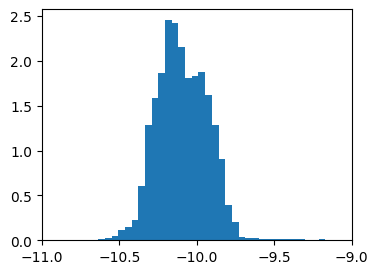

In [9]:
fig, axs = plt.subplots(1, 1, figsize=(4, 3))

plt.hist((logq - logp).ravel(), bins=1000, density=True);
plt.xlim([-11, -9]);

In [10]:
del y, logq, logp

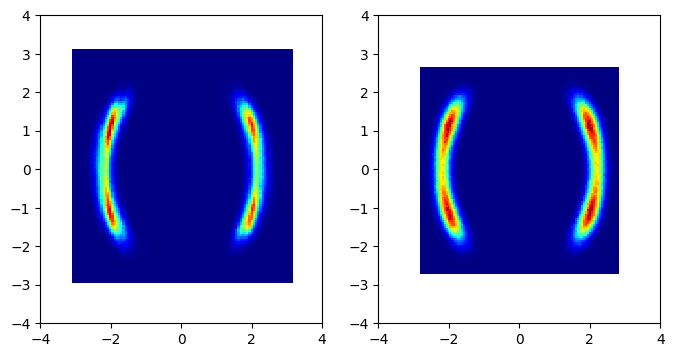

In [11]:
fig, axs = plt.subplots(1, 2, figsize=(8, 4))

for k, dist in enumerate([model1.posterior, model1.mcmc]):
    y = dist.sample(1000000)
    axs[k].hist2d(y[:, 0], y[:, 1], bins=100, cmap=plt.cm.jet);
    axs[k].set_xlim([-4, 4])
    axs[k].set_ylim([-4, 4])

del y

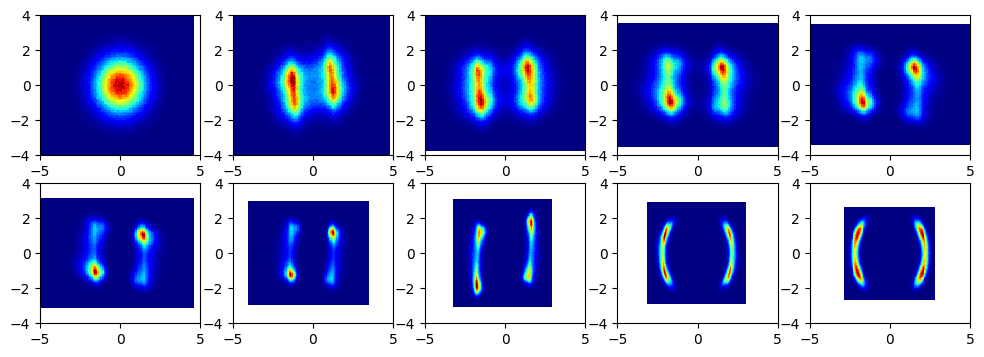

In [12]:
fig, axs = plt.subplots(2, 5, figsize=(12, 4))

x, logr = model1.prior.sample_(1000000)

stack = model1.net_.hack(x)

with torch.no_grad():
    y, logj = model1.net_(x)
    del x
    stack.append(model1.mcmc._accept_reject_step(y, logr - logj, -model1.action(y))[:2])

for k, (y, _) in enumerate(stack):
    y = y.detach()
    ax = axs[k // 5][k % 5]
    ax.hist2d(y[:, 0], y[:, 1], bins=100, cmap=plt.cm.jet);
    ax.set_xlim([-5, 5])
    ax.set_ylim([-4, 4])

del y, stack

fig.savefig("model1.pdf")

## Let us use ``normflow.nn.MultiPlanarFlow_`` and test it:

In [13]:
net_ = ModuleList_([normflow.nn.MultiPlanarFlow_(n=2, m=2) for _ in range(8)])

model1 = Model(prior=prior, net_=net_, action=Action1(5))

model1.net_.set_weights_blob(weights_blob)

y, logq, logp = model1.posterior.sample__(1024 * 64)
print(
    "ess = ", model1.train.calc_ess(logq, logp),
    "\naccept rate = ", np.mean(normflow.mcmc.mcmc.Metropolis().calc_accept_status(logq - logp))
)

ess =  tensor(0.9700) 
accept rate =  0.9027099609375
